In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("messy_ecommerce_15000_student_practice (1).csv")

df.head()

,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,2025-08-27,4.1,7.0,No,4263.19
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,2025-06-18,4.2,4.0,No,2982.06
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,UPI,2025-01-13,3.6,2.0,No,1319.80
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82


In [4]:
df.shape
df.info()
df.columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15075 non-null  object 
 1   Customer_ID       15075 non-null  object 
 2   Age               14804 non-null  float64
 3   Gender            14896 non-null  object 
 4   City              14925 non-null  object 
 5   Product_Category  15075 non-null  object 
 6   Product           15075 non-null  object 
 7   Quantity          15075 non-null  int64  
 8   Unit_Price        15075 non-null  float64
 9   Discount          14954 non-null  float64
 10  Payment_Method    14849 non-null  object 
 11  Order_Date        15075 non-null  object 
 12  Rating            14694 non-null  float64
 13  Delivery_Days     14895 non-null  float64
 14  Returned          15075 non-null  object 
 15  Total_Amount      15075 non-null  float64
dtypes: float64(6), int64(1), object(9)
memor

Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
dtype: object

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols)

df[numerical_cols].describe()

Index(['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days',
       'Total_Amount'],
      dtype='object')


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,14804.000000,15075.000000,15075.000000,14954.000000,14694.000000,14895.000000,1.507500e+04
mean,32.315185,1.899768,7409.180453,12.016852,3.869171,4.489359,1.255336e+04
std,9.022506,1.076839,13950.011077,7.696562,0.741548,1.961563,2.955080e+04
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02
25%,26.000000,1.000000,1248.315000,5.000000,3.400000,3.000000,1.742195e+03
50%,32.000000,2.000000,2480.280000,10.000000,3.900000,4.000000,3.223750e+03
75%,38.000000,2.000000,3811.455000,15.000000,4.400000,6.000000,7.739260e+03
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06


In [6]:
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

df[categorical_cols].describe()

Index(['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category',
       'Product', 'Payment_Method', 'Order_Date', 'Returned'],
      dtype='object')


,Order_ID,Customer_ID,Gender,City,Product_Category,Product,Payment_Method,Order_Date,Returned
count,15075,15075,14896,14925,15075,15075,14849,15075,15075
unique,15000,6795,5,12,6,30,8,730,3
top,ORD111361,CUST4633,Female,Kolkata,Electronics,Smartwatch,Credit Card,2026-05-29,No
freq,2,8,7292,1274,3815,798,2510,41,13229


In [7]:
print(df["Gender"].unique())
print(df["Payment_Method"].unique())
print(df["Returned"].unique())

['Male' 'Female' 'Other' nan 'female' 'male']
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']
['No' 'Yes' 'yes']


In [8]:
df.isnull().sum()

Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64

In [9]:
print(df.duplicated().sum())

duplicates = df[df.duplicated()]
display(duplicates)

df = df.drop_duplicates()

print(df.duplicated().sum())

75


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
232,ORD100933,CUST7882,38.0,NaN,Vijayawada,Fashion,Shoes,2,2815.57,5.0,UPI,2026-06-25,5.0,6.0,No,5349.58
1123,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,UPI,2026-09-03,3.8,7.0,No,2401.88
1274,ORD107827,CUST1775,39.0,Female,Ahmedabad,Sports,Cricket Bat,1,3188.13,5.0,UPI,2026-04-02,2.8,4.0,No,3028.72
2255,ORD111361,CUST7933,25.0,Male,Kolkata,Sports,Dumbbells,3,2207.60,15.0,Wallet,2025-09-29,5.0,3.0,No,5629.37
2311,ORD101796,CUST5636,43.0,Male,Pune,Fashion,T-Shirt,2,914.82,10.0,Net Banking,2026-07-16,3.3,5.0,No,1646.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,UPI,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


0


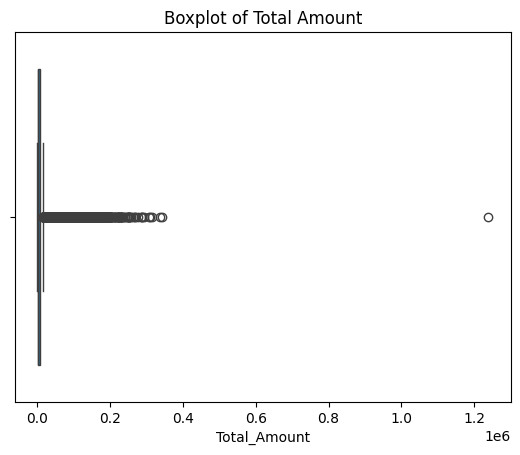

In [10]:
sns.boxplot(x=df["Total_Amount"])
plt.title("Boxplot of Total Amount")
plt.show()

In [11]:
Q1 = df["Total_Amount"].quantile(0.25)
Q3 = df["Total_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Total_Amount"] < lower) |
    (df["Total_Amount"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 2472


In [12]:
df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("messy_ecommerce_15000_student_practice (1).csv")

numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("\nStatistical Summary:")
display(df[numerical_cols].describe())

summary = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Standard Deviation": df[numerical_cols].std(),
    "Minimum": df[numerical_cols].min(),
    "25th Percentile": df[numerical_cols].quantile(0.25),
    "50th Percentile": df[numerical_cols].quantile(0.50),
    "75th Percentile": df[numerical_cols].quantile(0.75),
    "Maximum": df[numerical_cols].max()
})

display(summary)

range_analysis = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Range": df[numerical_cols].max() - df[numerical_cols].min()
})

print("\nRange Analysis:")
display(range_analysis.sort_values("Range", ascending=False))

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']

Statistical Summary:


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,14804.000000,15075.000000,15075.000000,14954.000000,14694.000000,14895.000000,1.507500e+04
mean,32.315185,1.899768,7409.180453,12.016852,3.869171,4.489359,1.255336e+04
std,9.022506,1.076839,13950.011077,7.696562,0.741548,1.961563,2.955080e+04
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02
25%,26.000000,1.000000,1248.315000,5.000000,3.400000,3.000000,1.742195e+03
50%,32.000000,2.000000,2480.280000,10.000000,3.900000,4.000000,3.223750e+03
75%,38.000000,2.000000,3811.455000,15.000000,4.400000,6.000000,7.739260e+03
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06


,Mean,Median,Standard Deviation,Minimum,25th Percentile,50th Percentile,75th Percentile,Maximum
Age,32.315185,32.00,9.022506,5.00,26.000,32.00,38.000,99.00
Quantity,1.899768,2.00,1.076839,1.00,1.000,2.00,2.000,5.00
Unit_Price,7409.180453,2480.28,13950.011077,425.61,1248.315,2480.28,3811.455,309655.38
Discount,12.016852,10.00,7.696562,0.00,5.000,10.00,15.000,30.00
Rating,3.869171,3.90,0.741548,1.00,3.400,3.90,4.400,5.00
Delivery_Days,4.489359,4.00,1.961563,1.00,3.000,4.00,6.000,14.00
Total_Amount,12553.357032,3223.75,29550.803498,298.27,1742.195,3223.75,7739.260,1238621.52



Range Analysis:


,Minimum,Maximum,Range
Total_Amount,298.27,1238621.52,1238323.25
Unit_Price,425.61,309655.38,309229.77
Age,5.00,99.00,94.00
Discount,0.00,30.00,30.00
Delivery_Days,1.00,14.00,13.00
Quantity,1.00,5.00,4.00
Rating,1.00,5.00,4.00


Observation: The numerical analysis shows that most customers are relatively young, with an average age of around 32 years. The average quantity purchased is about 2 items per order, while discounts range from 0% to 30%. Ratings are generally positive, with an average rating of around 3.87. Unit Price and Total Amount have large ranges, indicating the possibility of extreme values that should be investigated further.

In [14]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_cols))

Categorical Columns:
['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category', 'Product', 'Payment_Method', 'Order_Date', 'Returned']


In [15]:

df[categorical_cols].describe()

,Order_ID,Customer_ID,Gender,City,Product_Category,Product,Payment_Method,Order_Date,Returned
count,15075,15075,14896,14925,15075,15075,14849,15075,15075
unique,15000,6795,5,12,6,30,8,730,3
top,ORD111361,CUST4633,Female,Kolkata,Electronics,Smartwatch,Credit Card,2026-05-29,No
freq,2,8,7292,1274,3815,798,2510,41,13229


In [16]:

print("Number of Unique Values:")
display(df[categorical_cols].nunique())

print("Most Frequent Value:")
for col in categorical_cols:
    print(f"{col}: {df[col].mode()[0]}")

print("\nFrequency of Most Frequent Value:")
for col in categorical_cols:
    print(f"{col}: {df[col].value_counts().iloc[0]}")

Number of Unique Values:


Order_ID            15000
Customer_ID          6795
Gender                  5
City                   12
Product_Category        6
Product                30
Payment_Method          8
Order_Date            730
Returned                3
dtype: int64

Most Frequent Value:
Order_ID: ORD100150
Customer_ID: CUST1345
Gender: Female
City: Kolkata
Product_Category: Electronics
Product: Smartwatch
Payment_Method: Credit Card
Order_Date: 2026-05-29
Returned: No

Frequency of Most Frequent Value:
Order_ID: 2
Customer_ID: 8
Gender: 7292
City: 1274
Product_Category: 3815
Product: 798
Payment_Method: 2510
Order_Date: 41
Returned: 13229


In [17]:
print("Most Common Gender:")
print(df["Gender"].value_counts().head(1))

print("\nMost Common City:")
print(df["City"].value_counts().head(1))

print("\nMost Common Product Category:")
print(df["Product_Category"].value_counts().head(1))

print("\nMost Common Payment Method:")
print(df["Payment_Method"].value_counts().head(1))

print("\nMost Common Return Status:")
print(df["Returned"].value_counts().head(1))

Most Common Gender:
Gender
Female    7292
Name: count, dtype: int64

Most Common City:
City
Kolkata    1274
Name: count, dtype: int64

Most Common Product Category:
Product_Category
Electronics    3815
Name: count, dtype: int64

Most Common Payment Method:
Payment_Method
Credit Card    2510
Name: count, dtype: int64

Most Common Return Status:
Returned
No    13229
Name: count, dtype: int64


Observation: The categorical analysis shows the different categories present in the e-commerce dataset. The Gender, City, Product_Category, Payment_Method, and Returned columns contain categorical information. The unique and freq values help identify how many categories are present and which category occurs most frequently. The most common categories can also help us understand the general customer and purchasing patterns in the dataset.

In [18]:

print("Gender:")
print(df["Gender"].unique())

print("\nCity:")
print(df["City"].unique())

print("\nProduct Category:")
print(df["Product_Category"].unique())

print("\nPayment Method:")
print(df["Payment_Method"].unique())

print("\nReturned:")
print(df["Returned"].unique())

Gender:
['Male' 'Female' 'Other' nan 'female' 'male']

City:
['Hyderabad' 'Delhi' 'Pune' 'Chennai' 'Kolkata' 'Ahmedabad' 'Vijayawada'
 'Bengaluru' 'Guntur' 'Visakhapatnam' 'Warangal' 'Mumbai' nan]

Product Category:
['Fashion' 'Sports' 'Electronics' 'Home & Kitchen' 'Beauty' 'Books']

Payment Method:
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']

Returned:
['No' 'Yes' 'yes']


In [19]:


print("Number of unique Gender values:", df["Gender"].nunique())
print("Number of unique City values:", df["City"].nunique())
print("Number of unique Product Category values:", df["Product_Category"].nunique())
print("Number of unique Payment Method values:", df["Payment_Method"].nunique())
print("Number of unique Returned values:", df["Returned"].nunique())

Number of unique Gender values: 5
Number of unique City values: 12
Number of unique Product Category values: 6
Number of unique Payment Method values: 8
Number of unique Returned values: 3


In [20]:

for col in ["Gender", "City", "Product_Category", "Payment_Method", "Returned"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Female    7292
Male      7023
Other      441
male        80
female      60
Name: count, dtype: int64

--- City ---
City
Kolkata          1274
Vijayawada       1271
Ahmedabad        1268
Pune             1263
Guntur           1251
Hyderabad        1241
Bengaluru        1237
Warangal         1235
Delhi            1234
Visakhapatnam    1230
Chennai          1212
Mumbai           1209
Name: count, dtype: int64

--- Product_Category ---
Product_Category
Electronics       3815
Fashion           3296
Home & Kitchen    2707
Beauty            2147
Sports            1637
Books             1473
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Credit Card    2510
Net Banking    2490
Wallet         2485
UPI            2450
Debit Card     2444
COD            2390
upi              40
credit card      40
Name: count, dtype: int64

--- Returned ---
Returned
No     13229
Yes     1816
yes       30
Name: count, dtype: int64


1.How many unique values are present?
Gender: 5 unique values — Male, Female, Other, male, female
City: 12 unique values
Product_Category: 6 unique values
Payment_Method: 8 unique values — includes UPI/upi and Credit Card/credit card
Returned: 3 unique values — No, Yes, yes

2.Are there any unexpected values?
Yes. There are some inconsistent values caused by different capitalization:

Male and male
Female and female
UPI and upi
Credit Card and credit card
Yes and yes

3.Are there different representations of the same category?
Yes. The dataset contains different representations of the same categories. For example, Male and male represent the same gender, UPI and upi represent the same payment method, and Yes and yes represent the same return status.

In [21]:

print("Gender:")
print(df["Gender"].unique())

print("\nPayment Method:")
print(df["Payment_Method"].unique())

print("\nReturned:")
print(df["Returned"].unique())

Gender:
['Male' 'Female' 'Other' nan 'female' 'male']

Payment Method:
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']

Returned:
['No' 'Yes' 'yes']


In [22]:

df["Gender"] = df["Gender"].str.strip().str.title()

df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()

df["Returned"] = df["Returned"].str.strip().str.title()

In [23]:
print("Gender after standardization:")
print(df["Gender"].unique())

print("\nPayment Method after standardization:")
print(df["Payment_Method"].unique())

print("\nReturned after standardization:")
print(df["Returned"].unique())

Gender after standardization:
['Male' 'Female' 'Other' nan]

Payment Method after standardization:
['Debit Card' 'Upi' 'Cod' 'Net Banking' 'Credit Card' nan 'Wallet']

Returned after standardization:
['No' 'Yes']


Observation: The inconsistent categorical values were standardized successfully by removing extra spaces and using consistent capitalization. Values such as Male/male, Female/female, UPI/upi, Credit Card/credit card, and Yes/yes are now represented consistently.

In [24]:

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64


In [25]:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_summary[missing_summary["Missing Values"] > 0])

,Missing Values,Percentage
Age,271,1.797678
Gender,179,1.187396
City,150,0.995025
Discount,121,0.802653
Payment_Method,226,1.499171
Rating,381,2.527363
Delivery_Days,180,1.194030


In [26]:

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Discount"] = df["Discount"].fillna(df["Discount"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Delivery_Days"] = df["Delivery_Days"].fillna(df["Delivery_Days"].median())

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

print("Missing values have been handled.")

Missing values have been handled.


In [27]:

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Order_ID            0
Customer_ID         0
Age                 0
Gender              0
City                0
Product_Category    0
Product             0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Date          0
Rating              0
Delivery_Days       0
Returned            0
Total_Amount        0
dtype: int64


Observation: Missing values were found in seven columns: Age, Gender, City, Discount, Payment_Method, Rating, and Delivery_Days. Since the missing values were relatively small in percentage, numerical columns were filled using the median and categorical columns were filled using the mode. Median was selected for numerical columns because it is less affected by extreme values, while mode was appropriate for categorical columns. After treatment, the dataset was checked again to verify that the missing values were removed.

Observation: After applying the appropriate missing-value treatment, all missing values were successfully handled. The numerical columns were filled using the median, while categorical columns were filled using the mode. The final verification shows 0 missing values in all columns, so the dataset is now free from missing values.

In [28]:

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 75


In [29]:

duplicates = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicates)

Duplicate Records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,Upi,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


In [30]:

duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_IDs:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,Upi,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


Number of duplicate Order_IDs: 75


In [31]:

exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

print("Number of records with duplicate Order_ID:",
      df["Order_ID"].duplicated(keep=False).sum())

Number of exact duplicate rows: 75
Number of records with duplicate Order_ID: 150


In [32]:

missing_percentage_after = (df.isnull().sum() / len(df)) * 100

print("Missing-value percentage after treatment:")
print(missing_percentage_after)

Missing-value percentage after treatment:
Order_ID            0.0
Customer_ID         0.0
Age                 0.0
Gender              0.0
City                0.0
Product_Category    0.0
Product             0.0
Quantity            0.0
Unit_Price          0.0
Discount            0.0
Payment_Method      0.0
Order_Date          0.0
Rating              0.0
Delivery_Days       0.0
Returned            0.0
Total_Amount        0.0
dtype: float64


In [33]:

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("The dataset is completely free of missing values.")
else:
    print("The dataset still contains missing values.")

Total missing values: 0
The dataset is completely free of missing values.


In [34]:

print("Dataset dimensions before missing-value treatment: (15075, 16)")
print("Dataset dimensions after missing-value treatment:", df.shape)

Dataset dimensions before missing-value treatment: (15075, 16)
Dataset dimensions after missing-value treatment: (15075, 16)


In [35]:

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 75


In [36]:

duplicates = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicates)

Duplicate Records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,Upi,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


In [37]:

duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,Upi,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


Number of duplicate Order_ID values: 75


In [38]:

exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

Number of exact duplicate rows: 75


In [39]:

duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,Upi,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,Upi,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,Upi,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


Number of duplicate Order_ID values: 75


Observation: The dataset contains 75 duplicate rows. All 75 duplicates are exact duplicates, meaning the values in all 16 columns are identical to another record. When displaying duplicates using keep=False, 150 rows are shown because both the original and duplicate copies are displayed. These duplicate records can affect data analysis by increasing the frequency of certain transactions and producing inaccurate statistics and business insights.

In [40]:

records_before = len(df)

print("Records before removing duplicates:", records_before)

Records before removing duplicates: 15075


In [41]:

df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [42]:

duplicates_after = df.duplicated().sum()

print("Duplicate records after removal:", duplicates_after)

Duplicate records after removal: 0


In [43]:

print("Dataset dimensions after removing duplicates:", df.shape)

Dataset dimensions after removing duplicates: (15000, 16)


In [44]:

records_after = len(df)

print("Records before removing duplicates:", records_before)
print("Number of duplicate records:", duplicate_count)
print("Records after removing duplicates:", records_after)

Records before removing duplicates: 15075
Number of duplicate records: 75
Records after removing duplicates: 15000


Observation: There were 15,075 records in the dataset before duplicate removal. A total of 75 exact duplicate records were identified and removed. After removing the duplicates, the dataset contains 15,000 records and 16 columns. The verification confirms that there are now 0 duplicate records.

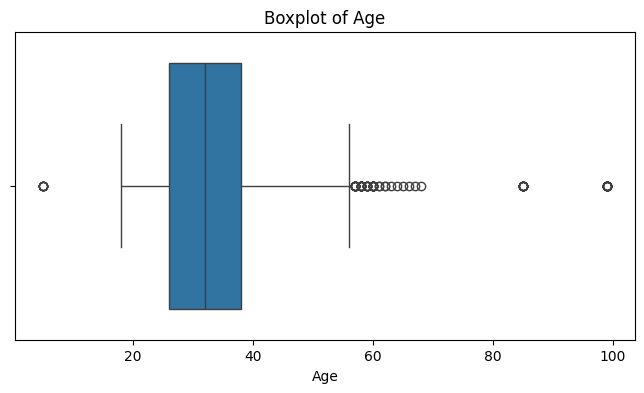

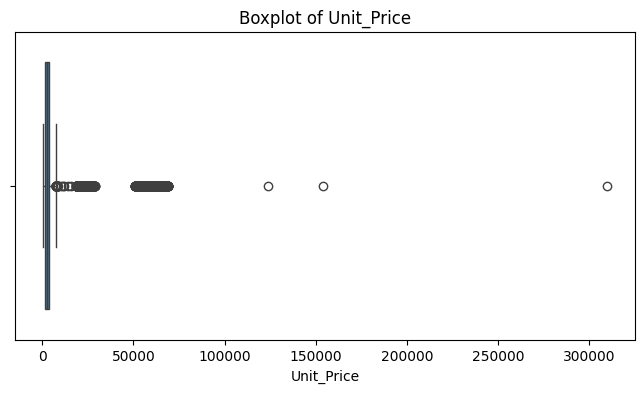

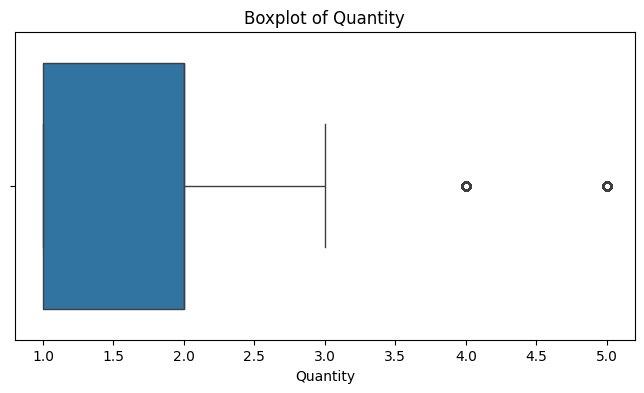

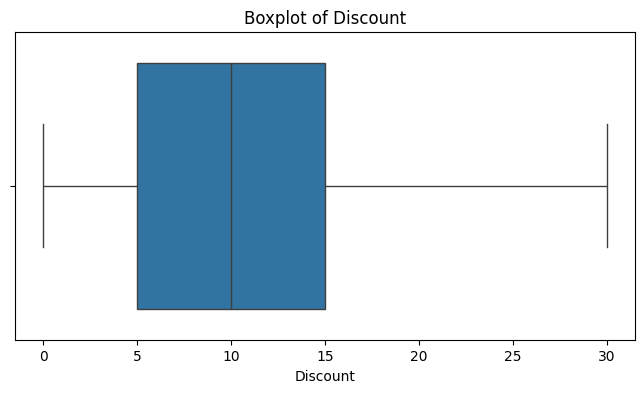

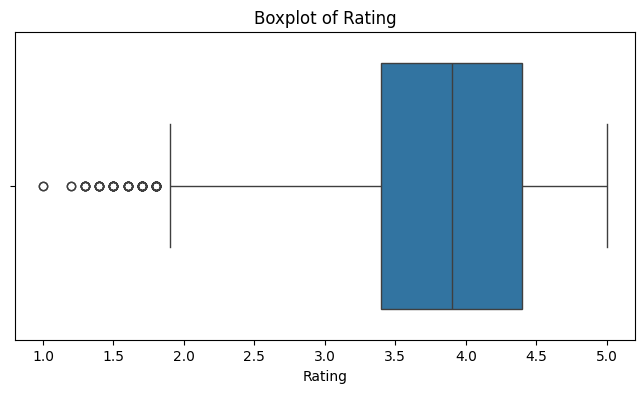

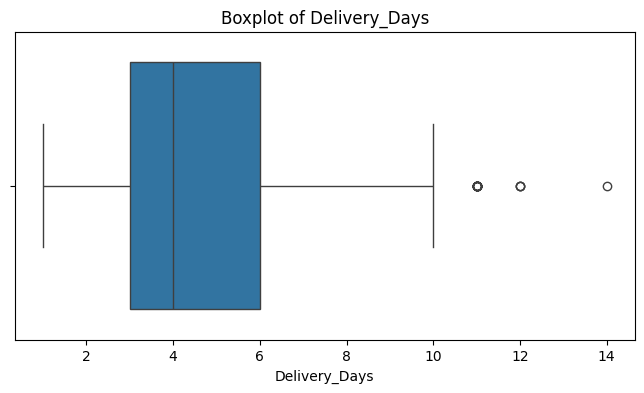

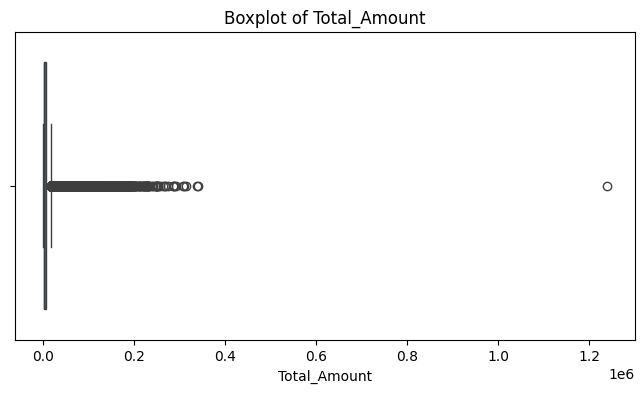

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

for col in columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [46]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"{col}: {len(outliers)} possible outliers")

Age: 90 possible outliers
Unit_Price: 2401 possible outliers
Quantity: 1513 possible outliers
Discount: 0 possible outliers
Rating: 73 possible outliers
Delivery_Days: 24 possible outliers
Total_Amount: 2472 possible outliers


1. Which columns contain possible outliers?

Age, Unit_Price, Quantity, Rating, Delivery_Days, and Total_Amount contain possible outliers. Discount does not show IQR-based outliers.

2. Which column appears to have the largest number of extreme values?

Total_Amount has the largest number of possible outliers, with 2,472, followed closely by Unit_Price with 2,401.

3. Are all outliers necessarily errors?

No. An outlier is not automatically an error. It can be a legitimate extreme value, such as a customer purchasing expensive products or placing a large order.

4. Which outliers require further investigation?

The extreme values in Unit_Price, Total_Amount, and Quantity require further investigation because they have a relatively large number of possible outliers. In particular, the very high values in Unit Price and Total Amount should be checked to determine whether they are genuine transactions or data-entry errors.


In [47]:

outlier_columns = ["Unit_Price", "Quantity", "Total_Amount"]

for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"\n--- {col} ---")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


--- Unit_Price ---
Q1: 1249.04
Q3: 3819.2974999999997
IQR: 2570.2574999999997
Lower Bound: -2606.3462499999996
Upper Bound: 7674.683749999999
Number of Outliers: 2401

--- Quantity ---
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
Number of Outliers: 1513

--- Total_Amount ---
Q1: 1741.9099999999999
Q3: 7741.01
IQR: 5999.1
Lower Bound: -7256.740000000002
Upper Bound: 16739.660000000003
Number of Outliers: 2472


In [48]:

for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"\nOutliers in {col}:")
    display(outliers)


Outliers in Unit_Price:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,Upi,2026-06-01,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,2026-06-07,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,2025-12-12,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,2026-09-13,4.9,6.0,No,65832.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15035,ORD102748,CUST6854,23.0,Male,Guntur,Electronics,Smartwatch,3,7861.75,5.0,Cod,2025-01-03,4.0,4.0,No,22405.99
15041,ORD111097,CUST4210,34.0,Female,Hyderabad,Electronics,Smartwatch,1,7837.06,10.0,Net Banking,2025-12-08,4.4,6.0,No,7053.35
15057,ORD108323,CUST6790,29.0,Female,Kolkata,Electronics,Laptop,2,64219.73,10.0,Wallet,2025-12-31,4.3,6.0,No,115595.51
15063,ORD104427,CUST6208,18.0,Female,Kolkata,Electronics,Tablet,3,22569.06,20.0,Net Banking,2026-03-07,3.5,3.0,No,54165.73



Outliers in Quantity:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
60,ORD105187,CUST1420,26.0,Female,Kolkata,Electronics,Headphones,5,3264.10,0.0,Net Banking,2025-05-07,3.3,5.0,No,16320.51
70,ORD103785,CUST7677,43.0,Male,Guntur,Home & Kitchen,Cookware Set,4,2454.31,15.0,Cod,2025-01-30,3.4,6.0,No,8344.64
74,ORD105050,CUST1031,30.0,Female,Hyderabad,Books,Biography,4,670.10,0.0,Wallet,2025-02-23,4.2,3.0,No,2680.39
75,ORD103479,CUST3967,25.0,Female,Vijayawada,Books,Biography,4,740.74,15.0,Cod,2025-05-29,4.0,2.0,No,2518.53
87,ORD108730,CUST7153,33.0,Male,Hyderabad,Fashion,T-Shirt,4,994.29,10.0,Upi,2025-05-16,2.6,5.0,No,3579.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15032,ORD100190,CUST7804,33.0,Female,Warangal,Fashion,Shoes,4,2677.68,10.0,Wallet,2025-02-02,2.9,8.0,No,9639.66
15040,ORD108667,CUST2789,18.0,Female,Pune,Fashion,Jeans,5,1673.65,10.0,Cod,2025-09-10,3.6,5.0,No,7531.43
15061,ORD114424,CUST8583,21.0,Female,Pune,Books,Biography,4,729.15,10.0,Debit Card,2026-04-12,2.8,4.0,No,2624.92
15065,ORD100467,CUST2595,39.0,Female,Visakhapatnam,Home & Kitchen,Bedsheet,4,1502.31,10.0,Net Banking,2025-10-16,4.3,4.0,Yes,5408.32



Outliers in Total_Amount:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,2026-06-17,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,2026-06-07,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,2025-12-12,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,2026-09-13,4.9,6.0,No,65832.03
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,2025-10-21,3.9,1.0,No,159469.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15034,ORD109168,CUST5003,30.0,Male,Guntur,Electronics,Laptop,3,66981.69,20.0,Net Banking,2025-12-27,4.5,3.0,No,160756.06
15035,ORD102748,CUST6854,23.0,Male,Guntur,Electronics,Smartwatch,3,7861.75,5.0,Cod,2025-01-03,4.0,4.0,No,22405.99
15057,ORD108323,CUST6790,29.0,Female,Kolkata,Electronics,Laptop,2,64219.73,10.0,Wallet,2025-12-31,4.3,6.0,No,115595.51
15063,ORD104427,CUST6208,18.0,Female,Kolkata,Electronics,Tablet,3,22569.06,20.0,Net Banking,2026-03-07,3.5,3.0,No,54165.73


In [49]:

iqr_summary = []

for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()
    
    iqr_summary.append([
        col, Q1, Q3, IQR,
        lower_bound, upper_bound,
        outlier_count
    ])

iqr_summary = pd.DataFrame(
    iqr_summary,
    columns=[
        "Column",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

display(iqr_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Unit_Price,1249.04,3819.2975,2570.2575,-2606.34625,7674.68375,2401
1,Quantity,1.00,2.0000,1.0000,-0.50000,3.50000,1513
2,Total_Amount,1741.91,7741.0100,5999.1000,-7256.74000,16739.66000,2472


Observation: The IQR method identified 2,401 possible outliers in Unit_Price, 1,513 in Quantity, and 2,472 in Total_Amount. Unit_Price has an upper bound of 7,674.68, while values above this limit are considered possible outliers. For Quantity, values above 3.5 are identified as possible outliers. Total_Amount has an upper bound of 16,739.66, so values above this amount are considered possible outliers. These values should be investigated before deciding whether they are errors or legitimate extreme values.

In [50]:

for col in ["Unit_Price", "Quantity", "Total_Amount"]:
    print(f"\nHighest values in {col}:")
    display(df[["Order_ID", "Product", "Quantity",
                "Unit_Price", "Discount", "Total_Amount"]]
            .sort_values(col, ascending=False)
            .head(10))


Highest values in Unit_Price:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
5675,ORD101964,Laptop,5,309655.38,20.0,1238621.52
13764,ORD103531,Smartphone,1,154227.90,0.0,154227.90
11408,ORD100728,Tablet,2,123970.50,0.0,247941.00
2122,ORD109554,Laptop,2,68965.28,10.0,124137.50
2703,ORD103284,Laptop,4,68959.27,20.0,220669.67
8868,ORD112870,Laptop,2,68957.87,20.0,110332.59
13657,ORD105780,Laptop,3,68938.69,20.0,165452.86
11413,ORD113412,Laptop,5,68922.62,10.0,310151.81
3629,ORD108415,Laptop,5,68905.11,15.0,292846.71
10775,ORD100973,Laptop,2,68845.60,5.0,130806.64



Highest values in Quantity:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
2708,ORD112751,Data Science Book,5,1044.51,10.0,4700.28
7581,ORD107880,Biography,5,722.25,10.0,3250.11
13929,ORD112762,Air Fryer,5,7246.07,5.0,34418.86
2355,ORD105427,Biography,5,577.22,25.0,2164.59
10505,ORD111952,Jacket,5,3011.95,10.0,13553.79
7629,ORD106998,Handbag,5,2105.21,5.0,9999.77
5174,ORD108484,Lamp,5,1046.57,25.0,3924.63
816,ORD110985,Perfume,5,1634.52,20.0,6538.08
818,ORD104169,Cookware Set,5,2473.63,15.0,10512.95
821,ORD105831,Face Wash,5,460.27,10.0,2071.24



Highest values in Total_Amount:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
5675,ORD101964,Laptop,5,309655.38,20.0,1238621.52
2553,ORD105227,Laptop,5,68243.58,0.0,341217.92
4789,ORD106128,Laptop,5,67549.30,0.0,337746.51
5850,ORD112225,Laptop,5,66257.21,5.0,314721.75
11413,ORD113412,Laptop,5,68922.62,10.0,310151.81
3003,ORD107104,Laptop,5,61536.85,0.0,307684.26
3629,ORD108415,Laptop,5,68905.11,15.0,292846.71
12523,ORD107233,Laptop,5,57647.50,0.0,288237.49
13229,ORD100131,Laptop,5,60424.07,5.0,287014.31
1738,ORD108950,Laptop,5,63319.10,10.0,284935.96


In [51]:

high_unit_price = df[df["Unit_Price"] > 7674.68375]

print("Number of high Unit_Price values:", len(high_unit_price))
display(high_unit_price[
    ["Order_ID", "Product", "Quantity", "Unit_Price",
     "Discount", "Total_Amount"]
].head(20))

Number of high Unit_Price values: 2401


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
3,ORD107927,Smartwatch,1,7739.89,10.0,6965.90
4,ORD105665,Laptop,1,61138.76,5.0,58081.82
9,ORD111336,Tablet,2,21716.46,10.0,39089.63
22,ORD100488,Tablet,2,19950.50,5.0,37905.95
35,ORD102406,Laptop,1,65832.03,0.0,65832.03
36,ORD106707,Smartwatch,1,7915.15,0.0,7915.15
38,ORD107857,Laptop,3,55954.27,5.0,159469.68
44,ORD104430,Laptop,1,68538.16,10.0,61684.35
58,ORD108383,Tablet,1,19498.77,10.0,17548.90
59,ORD111348,Smartphone,2,26179.31,30.0,36651.03


In [52]:

high_total = df[df["Total_Amount"] > 16739.66]

print("Number of high Total_Amount values:", len(high_total))
display(high_total[
    ["Order_ID", "Product", "Quantity", "Unit_Price",
     "Discount", "Total_Amount"]
].head(20))

Number of high Total_Amount values: 2472


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
4,ORD105665,Laptop,1,61138.76,5.0,58081.82
9,ORD111336,Tablet,2,21716.46,10.0,39089.63
22,ORD100488,Tablet,2,19950.50,5.0,37905.95
35,ORD102406,Laptop,1,65832.03,0.0,65832.03
38,ORD107857,Laptop,3,55954.27,5.0,159469.68
44,ORD104430,Laptop,1,68538.16,10.0,61684.35
58,ORD108383,Tablet,1,19498.77,10.0,17548.90
59,ORD111348,Smartphone,2,26179.31,30.0,36651.03
68,ORD104609,Smartphone,3,27616.08,15.0,70421.00
73,ORD111323,Air Fryer,3,7266.47,20.0,17439.54


In [53]:

high_quantity = df[df["Quantity"] > 3.5]

print("Number of high Quantity values:", len(high_quantity))
display(high_quantity[
    ["Order_ID", "Product", "Quantity",
     "Unit_Price", "Total_Amount"]
].head(20))

Number of high Quantity values: 1513


,Order_ID,Product,Quantity,Unit_Price,Total_Amount
60,ORD105187,Headphones,5,3264.10,16320.51
70,ORD103785,Cookware Set,4,2454.31,8344.64
74,ORD105050,Biography,4,670.10,2680.39
75,ORD103479,Biography,4,740.74,2518.53
87,ORD108730,T-Shirt,4,994.29,3579.44
91,ORD108404,Yoga Mat,5,978.62,3669.82
108,ORD101714,Running Shoes,5,3320.24,15771.14
120,ORD114156,Hair Dryer,4,2104.50,7997.10
143,ORD110625,Air Fryer,4,6402.91,21769.90
153,ORD105408,Smartphone,5,23987.38,107943.20


Observation: The IQR method identified several possible outliers in Unit_Price, Quantity, and Total_Amount. These values were not removed automatically because an outlier does not necessarily indicate an error. High Unit_Price and Total_Amount values may represent legitimate purchases of expensive products, while higher quantities may represent genuine bulk purchases. Therefore, these observations are treated as legitimate or suspicious values requiring further investigation rather than being removed without evidence of a data-entry error.

In [54]:

df["Expected_Total"] = (
    df["Unit_Price"] *
    df["Quantity"] *
    (1 - df["Discount"] / 100)
)

df[[
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total"
]].head(10)

,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total
0,2507.76,2,15.0,4263.19,4263.1920
1,1988.04,2,25.0,2982.06,2982.0600
2,776.35,2,15.0,1319.80,1319.7950
3,7739.89,1,10.0,6965.90,6965.9010
4,61138.76,1,5.0,58081.82,58081.8220
5,1890.11,1,10.0,1701.10,1701.0990
6,5999.83,1,15.0,5099.86,5099.8555
7,6760.65,1,20.0,5408.52,5408.5200
8,2830.42,2,5.0,5377.80,5377.7980
9,21716.46,2,10.0,39089.63,39089.6280


In [55]:

df["Difference"] = (
    df["Total_Amount"] - df["Expected_Total"]
)

df[[
    "Order_ID",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total",
    "Difference"
]].head(10)

,Order_ID,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Difference
0,ORD106680,2507.76,2,15.0,4263.19,4263.1920,-0.0020
1,ORD103291,1988.04,2,25.0,2982.06,2982.0600,0.0000
2,ORD106559,776.35,2,15.0,1319.80,1319.7950,0.0050
3,ORD107927,7739.89,1,10.0,6965.90,6965.9010,-0.0010
4,ORD105665,61138.76,1,5.0,58081.82,58081.8220,-0.0020
5,ORD106062,1890.11,1,10.0,1701.10,1701.0990,0.0010
6,ORD106614,5999.83,1,15.0,5099.86,5099.8555,0.0045
7,ORD103703,6760.65,1,20.0,5408.52,5408.5200,0.0000
8,ORD104915,2830.42,2,5.0,5377.80,5377.7980,0.0020
9,ORD111336,21716.46,2,10.0,39089.63,39089.6280,0.0020


In [56]:

large_differences = df.loc[
    df["Difference"].abs().sort_values(ascending=False).index
]

display(
    large_differences[
        [
            "Order_ID",
            "Product",
            "Quantity",
            "Unit_Price",
            "Discount",
            "Total_Amount",
            "Expected_Total",
            "Difference"
        ]
    ].head(20)
)

,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount,Expected_Total,Difference
15006,ORD109556,Laptop,3,51845.68,10.0,116652.78,139983.336,-23330.556
5821,ORD111725,Laptop,3,67905.26,10.0,203715.77,183344.202,20371.568
10442,ORD107033,Laptop,2,59340.16,10.0,94944.26,106812.288,-11868.028
645,ORD113636,Tablet,5,21130.97,10.0,105654.87,95089.365,10565.505
4796,ORD109508,Tablet,2,23281.56,10.0,46563.12,41906.808,4656.312
14977,ORD110174,Tablet,4,22117.21,10.0,84045.39,79621.956,4423.434
10042,ORD100671,Tablet,2,20937.19,10.0,33499.51,37686.942,-4187.432
2472,ORD110771,Smartwatch,2,8041.91,10.0,11258.67,14475.438,-3216.768
2549,ORD106416,Tablet,3,19674.08,10.0,50168.89,53120.016,-2951.126
10310,ORD107072,Smartphone,2,24851.88,10.0,47218.57,44733.384,2485.186


In [57]:

tolerance = 0.01

matching = df["Difference"].abs() <= tolerance
mismatching = df["Difference"].abs() > tolerance

print("Matching records:", matching.sum())
print("Mismatching records:", mismatching.sum())
print("Total records:", len(df))

Matching records: 13109
Mismatching records: 1891
Total records: 15000


In [58]:

print("Maximum absolute difference:",
      df["Difference"].abs().max())

print("Average absolute difference:",
      df["Difference"].abs().mean())

Maximum absolute difference: 23330.55600000001
Average absolute difference: 7.786710233333406


In [59]:

print("Dataset dimensions:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset dimensions: (15000, 18)
Number of rows: 15000
Number of columns: 18


In [60]:

print("Data Types:")
print(df.dtypes)

Data Types:
Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
Expected_Total      float64
Difference          float64
dtype: object


In [61]:

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [62]:

print("Total duplicate records:", df.duplicated().sum())

Total duplicate records: 0


In [63]:

for col in ["Gender", "City", "Product_Category",
            "Payment_Method", "Returned"]:
    print(f"{col}: {df[col].nunique()} unique values")

Gender: 3 unique values
City: 12 unique values
Product_Category: 6 unique values
Payment_Method: 6 unique values
Returned: 2 unique values


In [64]:

print("Gender:", df["Gender"].unique())
print("Payment Method:", df["Payment_Method"].unique())
print("Returned:", df["Returned"].unique())

Gender: ['Male' 'Female' 'Other']
Payment Method: ['Debit Card' 'Upi' 'Cod' 'Net Banking' 'Credit Card' 'Wallet']
Returned: ['No' 'Yes']


In [65]:

df.describe()

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount,Expected_Total,Difference
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,1.500000e+04,15000.000000
mean,32.303267,1.899000,7417.831243,12.008000,3.869920,4.483800,1.256593e+04,1.256715e+04,-1.223788
std,8.939461,1.076635,13958.314015,7.667802,0.732387,1.950656,2.956941e+04,2.956691e+04,296.669279
min,5.000000,1.000000,425.610000,0.000000,1.000000,1.000000,2.982700e+02,2.982700e+02,-23330.556000
25%,26.000000,1.000000,1249.040000,5.000000,3.400000,3.000000,1.741910e+03,1.741450e+03,-0.004000
50%,32.000000,2.000000,2480.995000,10.000000,3.900000,4.000000,3.226920e+03,3.227758e+03,0.000000
75%,38.000000,2.000000,3819.297500,15.000000,4.400000,6.000000,7.741010e+03,7.742276e+03,0.004000
max,99.000000,5.000000,309655.380000,30.000000,5.000000,14.000000,1.238622e+06,1.238622e+06,20371.568000


In [66]:

print("Order_Date data type before conversion:")
print(df["Order_Date"].dtype)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("\nOrder_Date data type after conversion:")
print(df["Order_Date"].dtype)

print("\nInvalid dates:", df["Order_Date"].isna().sum())

Order_Date data type before conversion:
object

Order_Date data type after conversion:
datetime64[ns]

Invalid dates: 0


In [67]:

print("Records matching expected amount:", matching.sum())
print("Records with differences:", mismatching.sum())
print("Average absolute difference:",
      df["Difference"].abs().mean())

Records matching expected amount: 13109
Records with differences: 1891
Average absolute difference: 7.786710233333406


Yes, the dataset is ready for exploratory data analysis. Missing values have been handled, duplicate records have been removed, categorical inconsistencies have been standardized, data types have been checked, and outliers and data-consistency issues have been identified. The remaining extreme values and inconsistent Total Amount records should be considered when interpreting the EDA results.

In [68]:

df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [69]:
import os

print(os.path.exists("cleaned_ecommerce_dataset.csv"))

True


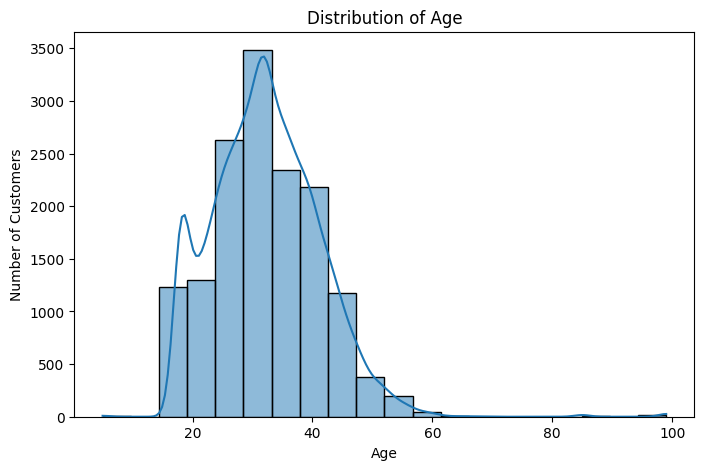

In [70]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Observation: The histogram shows the distribution of customer ages. Most customers are concentrated in the younger and middle-age groups, while fewer customers are present at the higher age ranges.

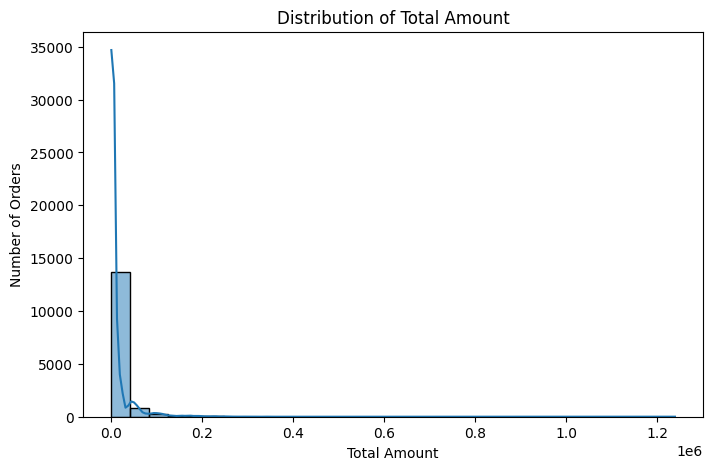

In [71]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Total_Amount", bins=30, kde=True)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Orders")
plt.show()

Observation: The Total Amount distribution is right-skewed, with most orders having relatively lower values and a smaller number of orders having very high total amounts.

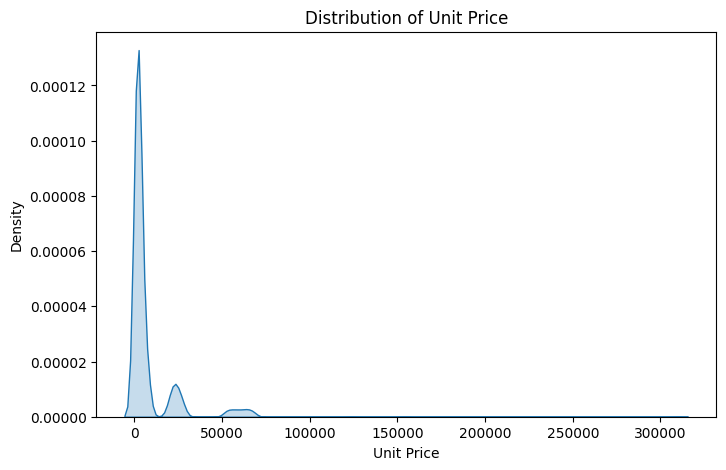

In [72]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Unit_Price", fill=True)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.show()

Observation: The KDE plot shows that most products have lower unit prices, while a smaller number of products have considerably higher prices, creating a right-skewed distribution.

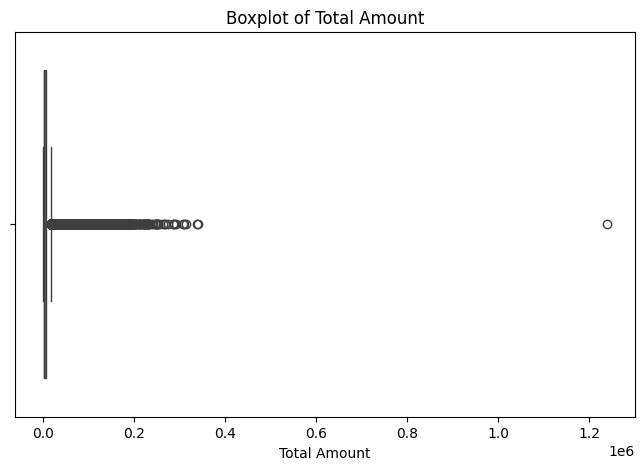

In [73]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Total_Amount")

plt.title("Boxplot of Total Amount")
plt.xlabel("Total Amount")
plt.show()

Observation: The boxplot shows that most Total Amount values are concentrated within a relatively smaller range, while several high-value orders appear as possible outliers.

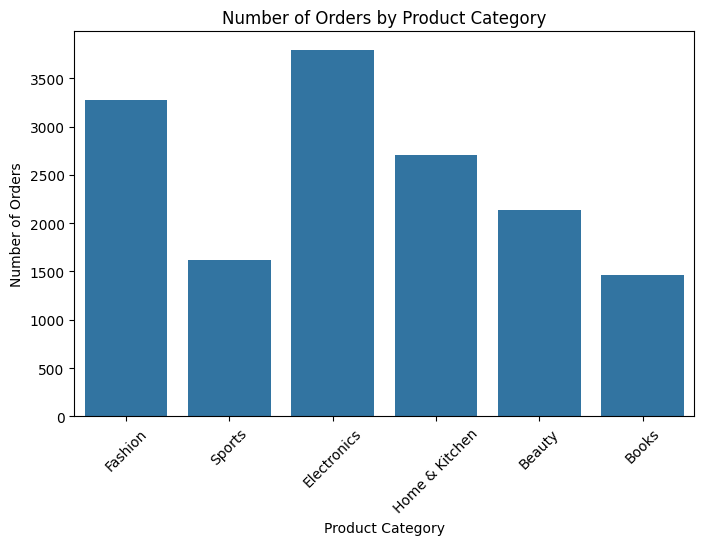

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Product_Category")

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Observation: The countplot shows the number of orders across different product categories. It helps identify which product categories are more frequently purchased and which have comparatively fewer orders.

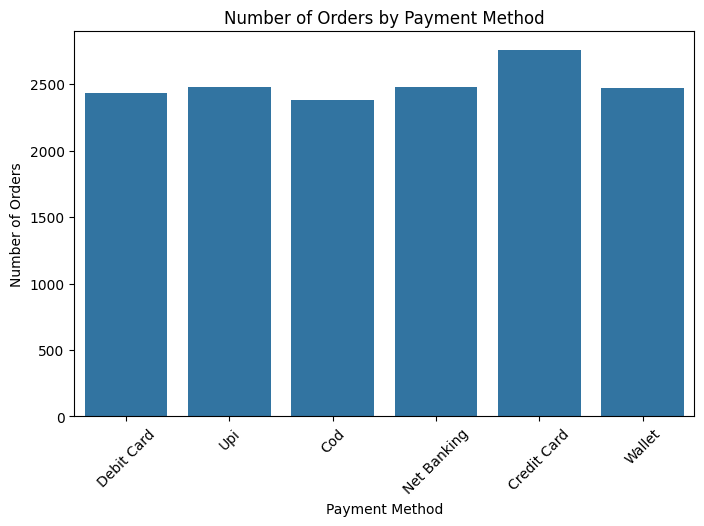

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Payment_Method")

plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Observation: The countplot shows the distribution of orders across different payment methods. It helps identify the most commonly used payment method among customers.

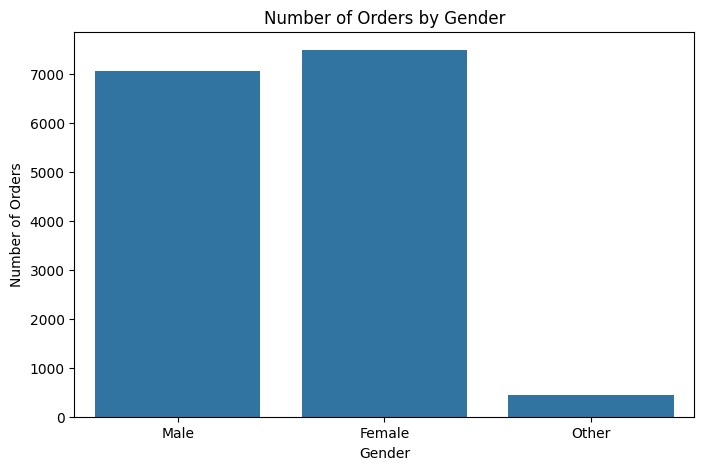

In [76]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender")

plt.title("Number of Orders by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.show()

Observation: The countplot shows the distribution of orders across different gender categories. It helps compare the number of orders associated with each gender.

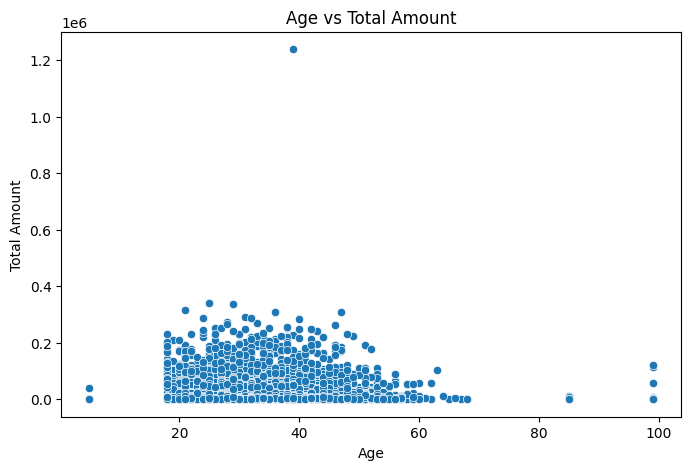

In [77]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Amount"
)

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

Observation: The scatter plot shows the relationship between customer age and total order amount. The points are widely distributed, indicating that age does not have a strong direct relationship with the total amount spent.

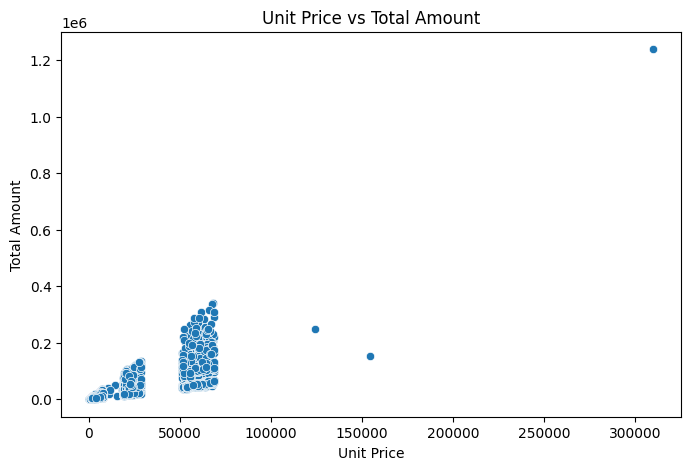

In [78]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Total_Amount"
)

plt.title("Unit Price vs Total Amount")
plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.show()

Observation: The plot shows a positive relationship between Unit Price and Total Amount. Orders with higher-priced products generally tend to have higher total amounts, although quantity and discount also influence the final amount.

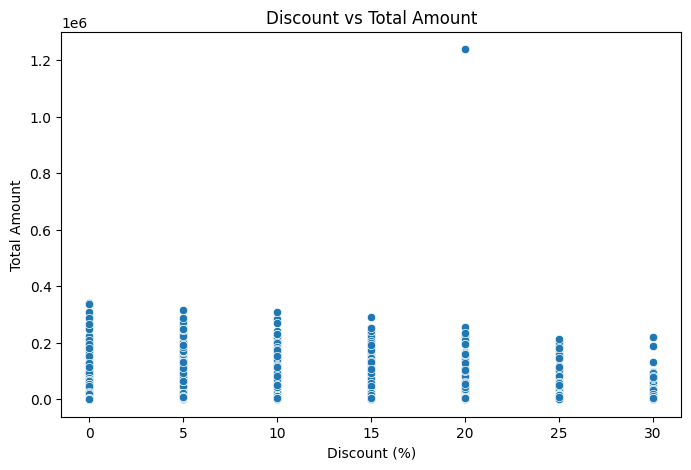

In [79]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Total_Amount"
)

plt.title("Discount vs Total Amount")
plt.xlabel("Discount (%)")
plt.ylabel("Total Amount")
plt.show()

Observation: The scatter plot shows the relationship between discount percentage and total order amount. The points are spread across different discount levels, suggesting that discount alone does not strongly determine the total amount.

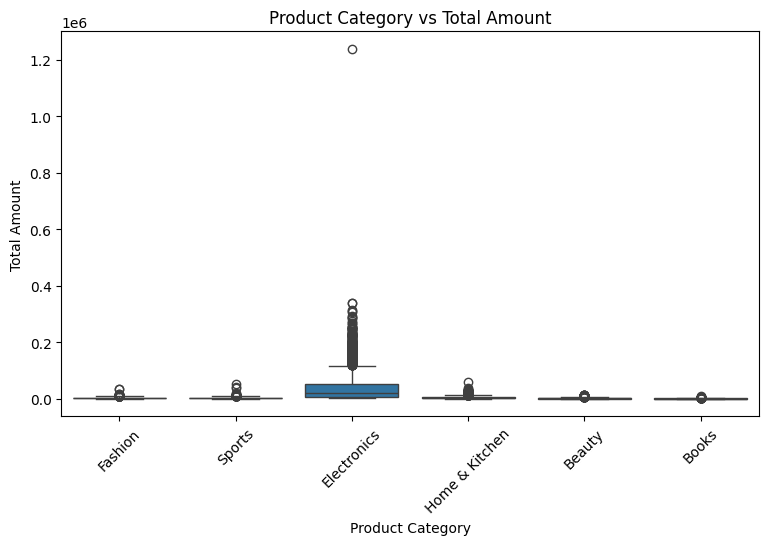

In [80]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Product_Category",
    y="Total_Amount"
)

plt.title("Product Category vs Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

Observation: The boxplot shows differences in Total Amount across product categories. Some categories have higher typical order values than others, while several categories also contain high-value orders and possible outliers.

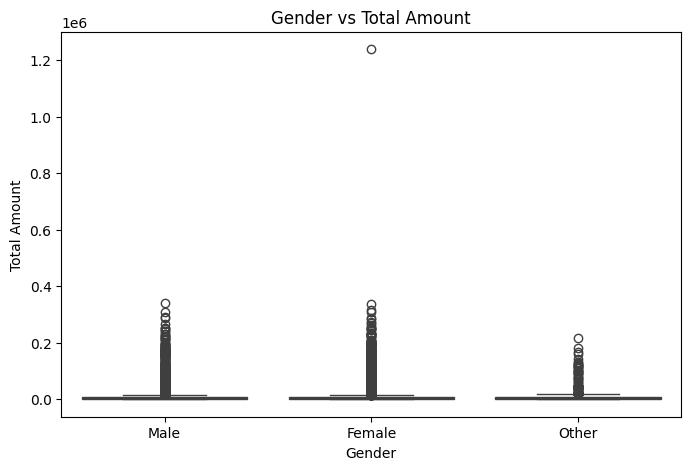

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Total_Amount"
)

plt.title("Gender vs Total Amount")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

Observation: The boxplot compares spending patterns across gender categories. The distributions show that customers from different gender categories have some variation in their total order amounts, although there is considerable overlap.

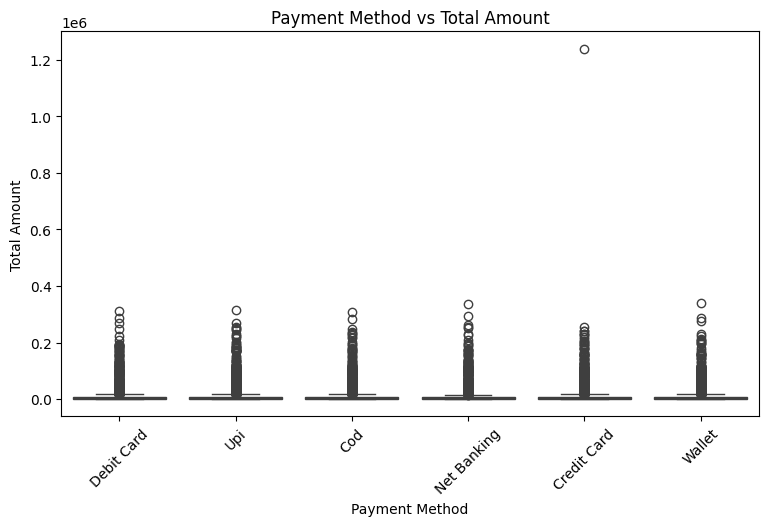

In [82]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Payment_Method",
    y="Total_Amount"
)

plt.title("Payment Method vs Total Amount")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

Observation: The boxplot compares Total Amount across different payment methods. The distributions are useful for understanding whether customers using different payment methods tend to have different spending patterns.

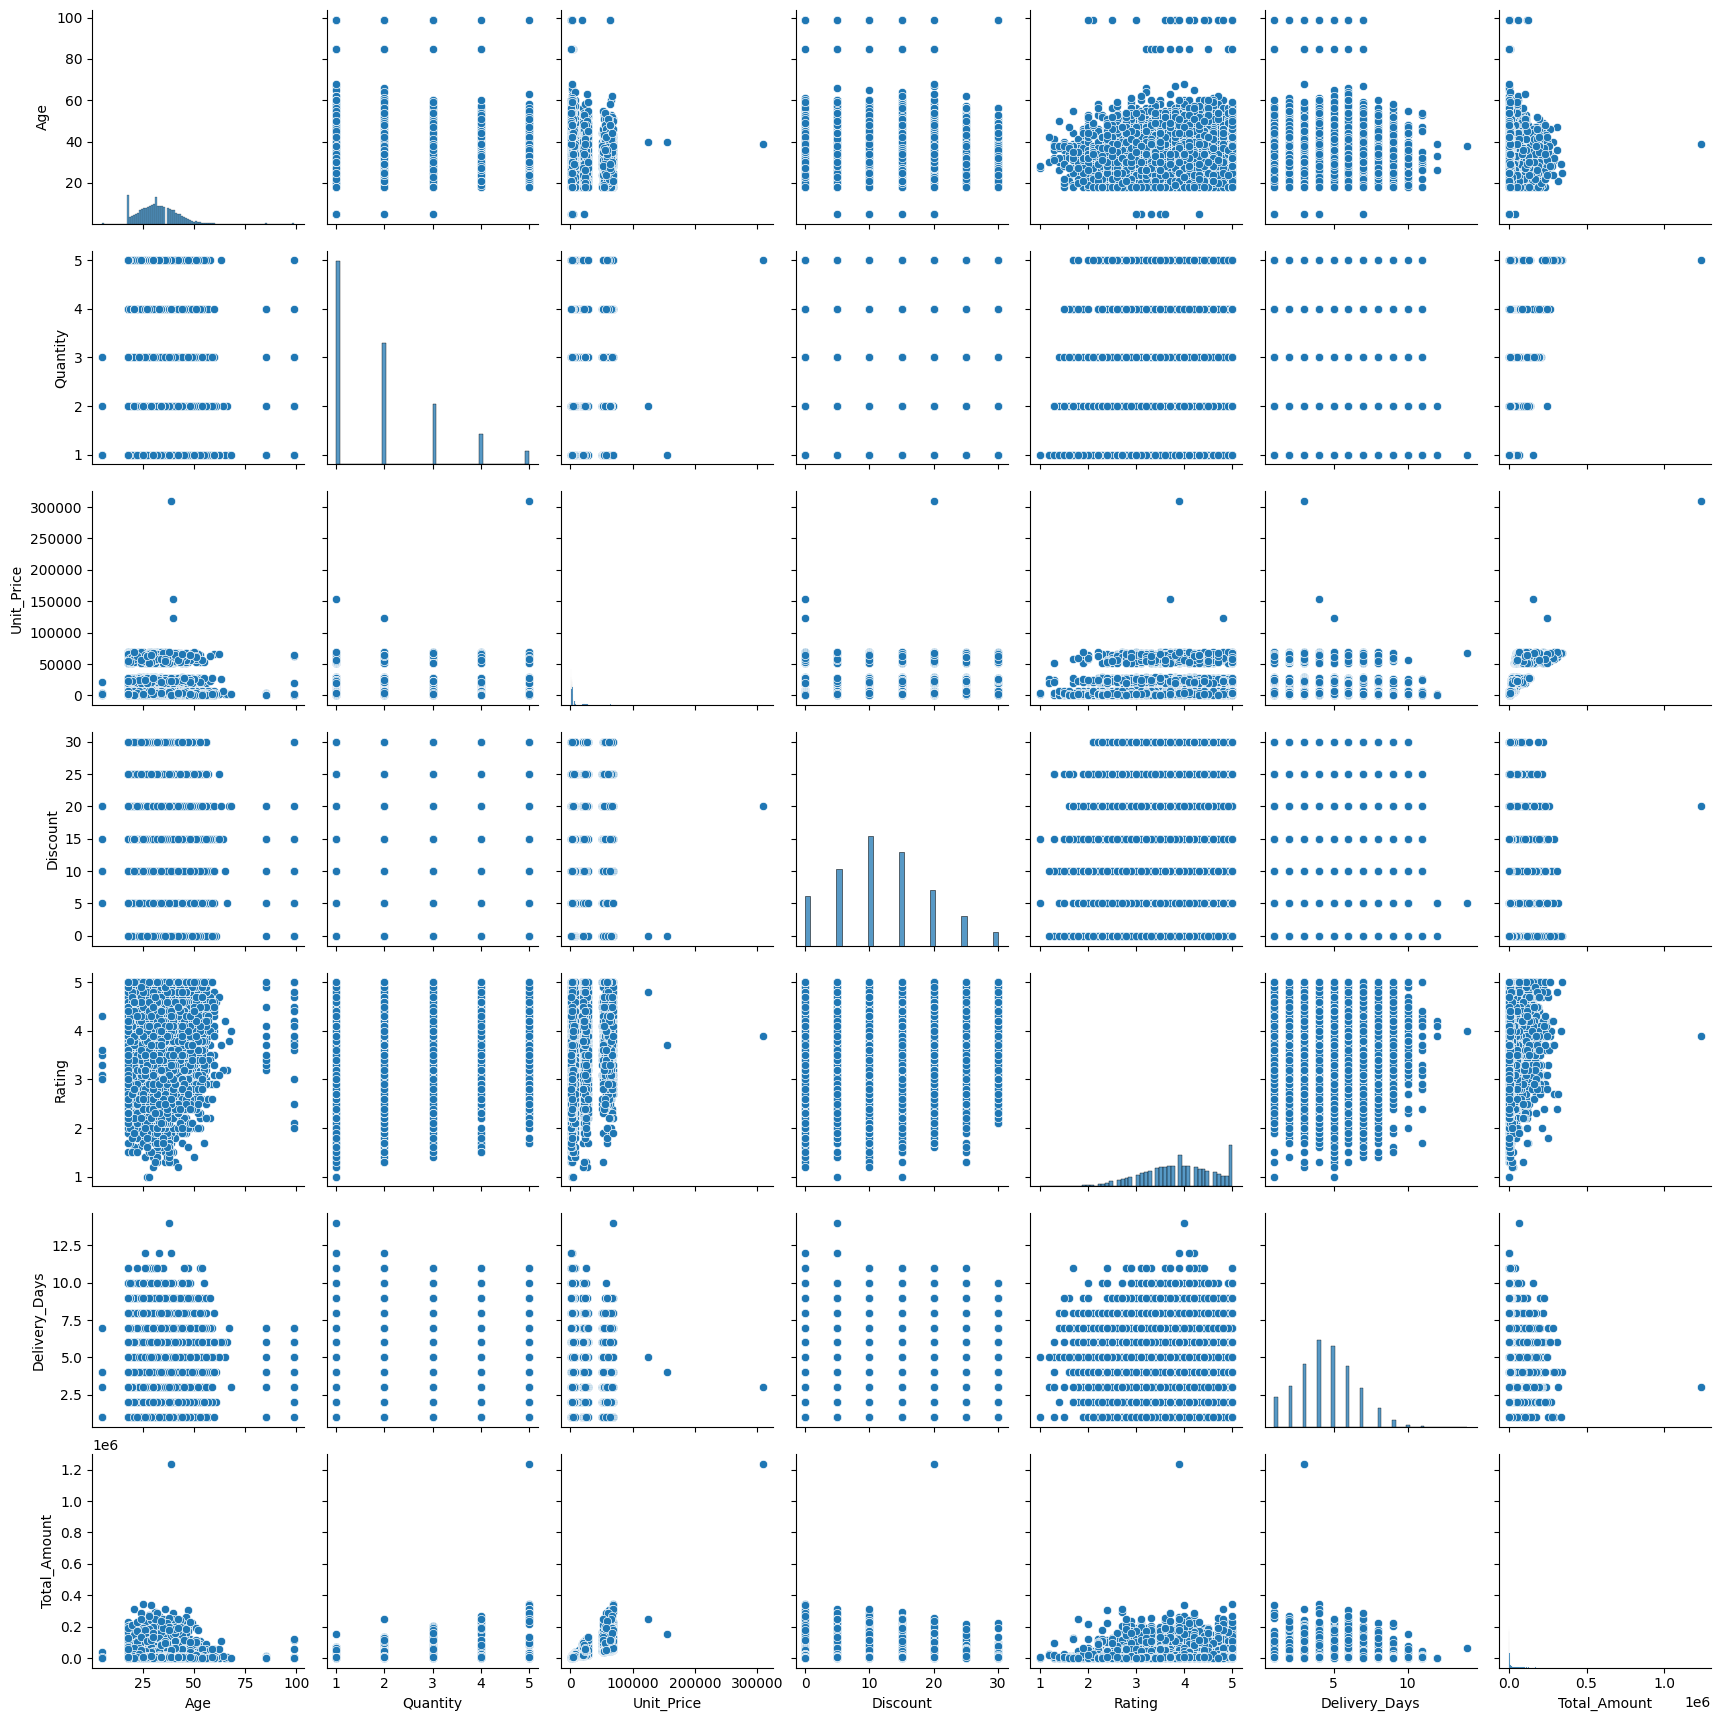

In [83]:

pairplot_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

sns.pairplot(df[pairplot_cols])

plt.show()

Observation: The pairplot shows the relationships and distributions among the selected numerical variables. Unit Price and Total Amount show a noticeable positive relationship, while some other variables have weaker relationships. The diagonal plots show the individual distributions of the numerical variables.

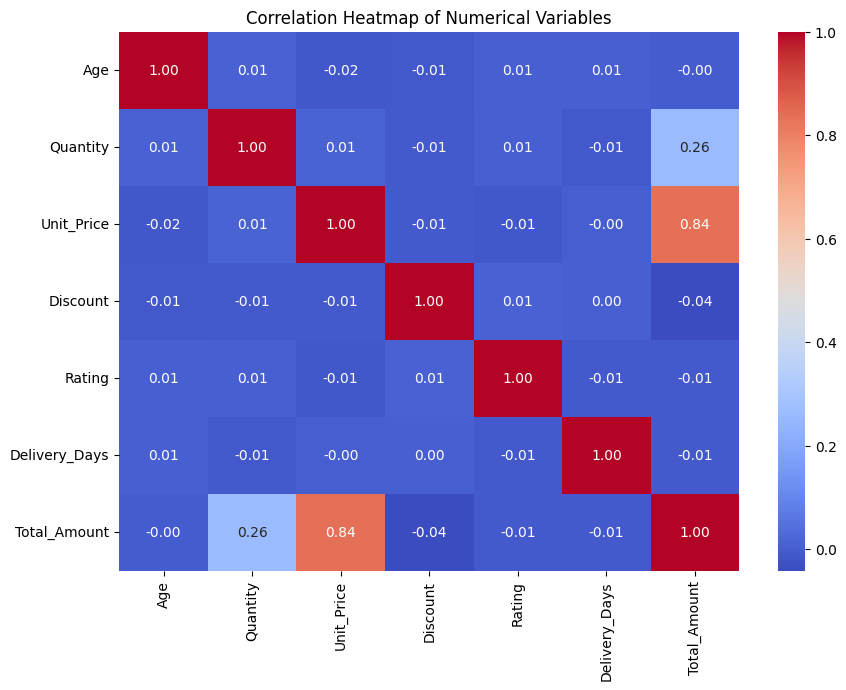

In [ ]:

correlation_matrix = df[pairplot_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Observation: The correlation heatmap shows the strength and direction of relationships between numerical variables. Unit Price and Total Amount have a positive relationship, while some other variables show weak correlations. The heatmap makes it easier to identify which variables may be useful for understanding Total Amount.

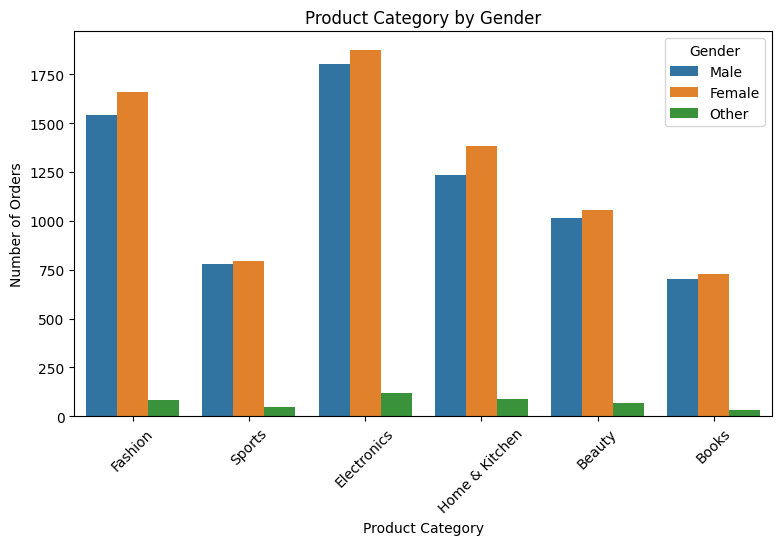

In [85]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Gender"
)

plt.title("Product Category by Gender")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Observation: The countplot compares product category preferences across different gender groups. It helps identify which product categories have higher or lower numbers of orders for each gender.

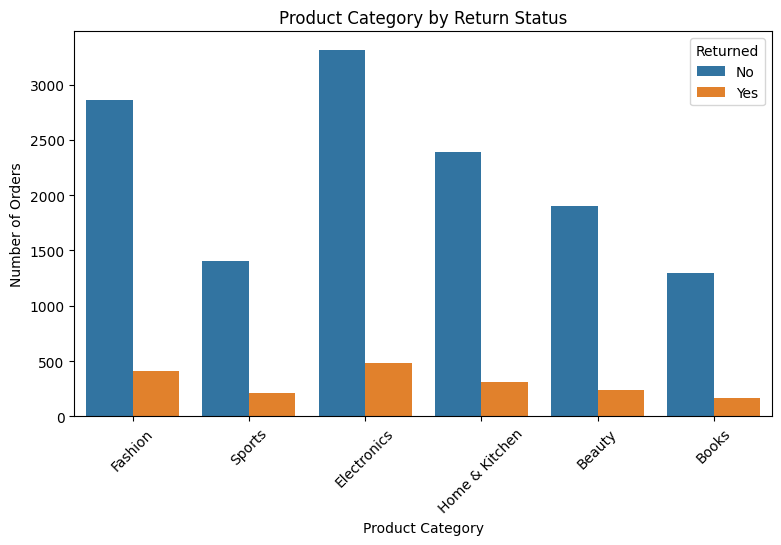

In [86]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Returned"
)

plt.title("Product Category by Return Status")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Observation: The plot compares return status across product categories. It helps identify categories with relatively more returned and non-returned orders.

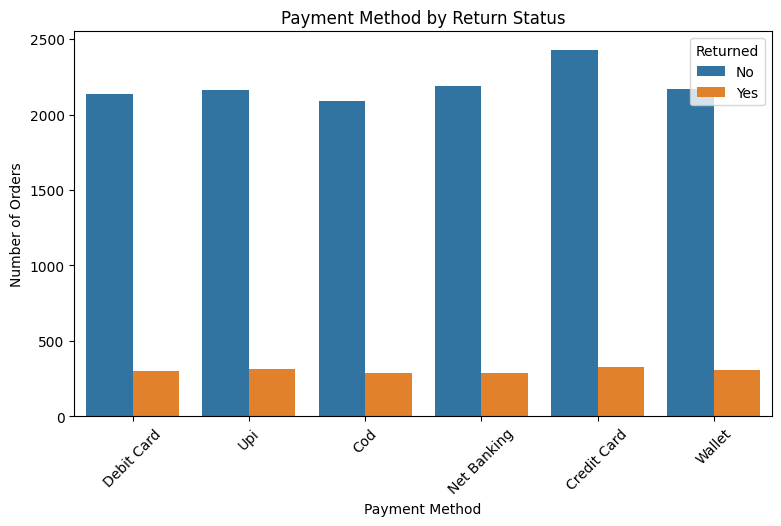

In [87]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Returned"
)

plt.title("Payment Method by Return Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Observation: The visualization compares return status across different payment methods. It helps identify whether returned and non-returned orders are distributed differently among payment methods.

In [88]:

numerical_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix)

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
Age,1.000000,0.011426,-0.016544,-0.009784,0.005734,0.006673,-0.004330
Quantity,0.011426,1.000000,0.012130,-0.005515,0.007088,-0.009716,0.255942
Unit_Price,-0.016544,0.012130,1.000000,-0.005659,-0.014778,-0.000417,0.835066
Discount,-0.009784,-0.005515,-0.005659,1.000000,0.007764,0.004916,-0.041234
Rating,0.005734,0.007088,-0.014778,0.007764,1.000000,-0.007873,-0.008006
Delivery_Days,0.006673,-0.009716,-0.000417,0.004916,-0.007873,1.000000,-0.007124
Total_Amount,-0.004330,0.255942,0.835066,-0.041234,-0.008006,-0.007124,1.000000


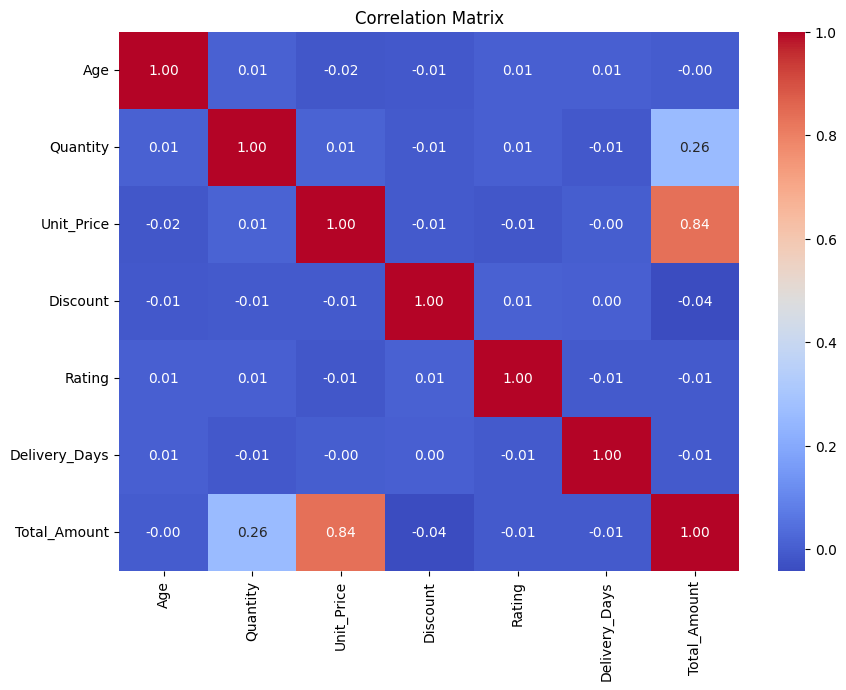

In [89]:

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [90]:

corr_without_self = correlation_matrix.copy()

np.fill_diagonal(corr_without_self.values, np.nan)

strongest_positive = corr_without_self.stack().idxmax()
positive_value = corr_without_self.stack().max()

strongest_negative = corr_without_self.stack().idxmin()
negative_value = corr_without_self.stack().min()

print("Strongest Positive Correlation:")
print(strongest_positive, "=", positive_value)

print("\nStrongest Negative Correlation:")
print(strongest_negative, "=", negative_value)

Strongest Positive Correlation:
('Unit_Price', 'Total_Amount') = 0.8350661199581896

Strongest Negative Correlation:
('Discount', 'Total_Amount') = -0.0412337856257941


In [91]:

total_amount_corr = (
    correlation_matrix["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(ascending=False)
)

print("Correlation with Total Amount:")
display(total_amount_corr)

Correlation with Total Amount:


Unit_Price       0.835066
Quantity         0.255942
Age             -0.004330
Delivery_Days   -0.007124
Rating          -0.008006
Discount        -0.041234
Name: Total_Amount, dtype: float64

In [92]:

weak_correlations = total_amount_corr[
    total_amount_corr.abs() < 0.3
]

print("Weak correlations with Total Amount:")
display(weak_correlations)

Weak correlations with Total Amount:


Quantity         0.255942
Age             -0.004330
Delivery_Days   -0.007124
Rating          -0.008006
Discount        -0.041234
Name: Total_Amount, dtype: float64

1. Strongest positive correlation:
Unit_Price and Total_Amount = 0.8351

This is a strong positive correlation, meaning higher unit prices are generally associated with higher total order amounts.

2. Strongest negative correlation:
Discount and Total_Amount = -0.0412

This is a very weak negative correlation, so discount has almost no linear relationship with Total Amount in this dataset.

3. Variables with weak correlation with Total Amount:

Age = -0.0043
Delivery_Days = -0.0071
Rating = -0.0080
Discount = -0.0412

Quantity has a weak-to-moderate positive correlation with Total Amount at 0.2559.

4. Variables that may be useful for predicting Total Amount:

Unit_Price (0.8351) — strongest relationship
Quantity (0.2559) — some positive relationship


Final Question

Which features appear to have the strongest relationship with Total Amount?

Answer: Unit_Price has the strongest relationship with Total_Amount (0.8351), followed by Quantity (0.2559). Therefore, these two features appear to be the most useful numerical variables for understanding Total Amount.

In [93]:
category_orders = df["Product_Category"].value_counts()

print("Orders by Product Category:")
display(category_orders)

print("Most ordered category:",
      category_orders.idxmax())

Orders by Product Category:


Product_Category
Electronics       3796
Fashion           3278
Home & Kitchen    2703
Beauty            2136
Sports            1621
Books             1466
Name: count, dtype: int64

Most ordered category: Electronics


In [94]:
avg_category_amount = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Total Amount by Product Category:")
display(avg_category_amount)

print("Category with highest average order value:",
      avg_category_amount.idxmax())

Average Total Amount by Product Category:


Product_Category
Electronics       39440.436399
Home & Kitchen     5126.773696
Sports             3772.829402
Fashion            3444.718261
Beauty             2624.780431
Books              1296.911357
Name: Total_Amount, dtype: float64

Category with highest average order value: Electronics


In [95]:
payment_orders = df["Payment_Method"].value_counts()

print("Orders by Payment Method:")
display(payment_orders)

print("Most popular payment method:",
      payment_orders.idxmax())

Orders by Payment Method:


Payment_Method
Credit Card    2758
Upi            2479
Net Banking    2477
Wallet         2472
Debit Card     2435
Cod            2379
Name: count, dtype: int64

Most popular payment method: Credit Card


In [96]:
city_sales = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by City:")
display(city_sales)

print("City with highest sales:",
      city_sales.idxmax())

Sales by City:


City
Kolkata          17425135.10
Ahmedabad        17245306.03
Bengaluru        17117279.63
Delhi            16524428.75
Visakhapatnam    16422064.54
Pune             16332191.21
Vijayawada       15794250.66
Warangal         15417724.72
Hyderabad        14870454.17
Chennai          13938707.06
Mumbai           13756886.96
Guntur           13644483.01
Name: Total_Amount, dtype: float64

City with highest sales: Kolkata


In [97]:
gender_spending = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average spending by Gender:")
display(gender_spending)

print("Gender with highest average spending:",
      gender_spending.idxmax())

Average spending by Gender:


Gender
Other     13962.821686
Female    12925.201959
Male      12098.170318
Name: Total_Amount, dtype: float64

Gender with highest average spending: Other


In [98]:
discount_correlation = df["Discount"].corr(df["Total_Amount"])

print("Correlation between Discount and Total Amount:",
      discount_correlation)

Correlation between Discount and Total Amount: -0.041233785625794245


In [99]:
product_rating = (
    df.groupby("Product")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Product:")
display(product_rating)

print("Highest-rated product:",
      product_rating.idxmax())

Average Rating by Product:


Product
Hair Dryer           3.992272
Yoga Mat             3.940753
Perfume              3.923250
Exam Guide           3.918027
Dumbbells            3.904682
Bedsheet             3.902677
Data Science Book    3.901866
Jeans                3.896444
Handbag              3.892390
Air Fryer            3.891871
Smartwatch           3.887863
Moisturizer          3.886946
Face Wash            3.885649
Smartphone           3.867112
Headphones           3.865517
Mixer Grinder        3.865177
Football             3.862963
Tablet               3.858808
Lamp                 3.857458
Jacket               3.855162
Shoes                3.849020
Makeup Kit           3.844898
Cookware Set         3.843893
Running Shoes        3.843380
T-Shirt              3.841167
Novel                3.828077
Laptop               3.818331
Cricket Bat          3.812251
Programming Book     3.812179
Biography            3.784337
Name: Rating, dtype: float64

Highest-rated product: Hair Dryer


In [100]:
return_percentage = (
    df["Returned"].value_counts(normalize=True) * 100
)

print("Return Percentage:")
display(return_percentage)

print("Percentage of returned orders:",
      return_percentage.get("Yes", 0))

Return Percentage:


Returned
No     87.793333
Yes    12.206667
Name: proportion, dtype: float64

Percentage of returned orders: 12.206666666666667


In [101]:
delivery_rating_corr = df["Delivery_Days"].corr(df["Rating"])

print("Correlation between Delivery Days and Rating:",
      delivery_rating_corr)

Correlation between Delivery Days and Rating: -0.007873280458458474


In [102]:
total_amount_correlations = (
    df[
        [
            "Age",
            "Quantity",
            "Unit_Price",
            "Discount",
            "Rating",
            "Delivery_Days",
            "Total_Amount"
        ]
    ]
    .corr()["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(ascending=False)
)

print("Correlation with Total Amount:")
display(total_amount_correlations)

Correlation with Total Amount:


Unit_Price       0.835066
Quantity         0.255942
Age             -0.004330
Delivery_Days   -0.007124
Rating          -0.008006
Discount        -0.041234
Name: Total_Amount, dtype: float64

E-Commerce Data Analysis — Final Report


1. Dataset Description

The dataset contains e-commerce order information with customer, product, payment, order, rating, delivery, return, and sales-related details. The dataset initially contained 15,075 records and 16 columns. The analysis was performed using Pandas, Matplotlib, and Seaborn.

2. Data Quality Problems Identified

The dataset contained several data-quality issues:

Missing values were present in 7 columns: Age, Gender, City, Discount, Payment_Method, Rating, and Delivery_Days.
Inconsistent categorical values were found, such as Male/male, Female/female, UPI/upi, Credit Card/credit card, and Yes/yes.
The dataset contained 75 exact duplicate records.
Several numerical columns contained possible outliers, particularly Unit_Price, Quantity, and Total_Amount.
Some records had differences between the calculated expected Total Amount and the existing Total Amount.

3. Data Cleaning Techniques Used

Missing numerical values were replaced using the median, while missing categorical values were replaced using the mode. Categorical values were standardized to maintain consistent formatting. The 75 exact duplicate records were removed, reducing the dataset from 15,075 to 15,000 records.

Outliers were investigated using Seaborn boxplots and the IQR method. The outliers were not automatically removed because some extreme values may represent legitimate transactions.

4. Exploratory Data Analysis

Univariate, bivariate, and multivariate analyses were performed using Seaborn. Histograms, KDE plots, boxplots, countplots, scatterplots, pairplots, and a correlation heatmap were used to understand distributions and relationships between variables.

The correlation analysis showed that Unit_Price has the strongest positive relationship with Total_Amount (0.8351), followed by Quantity (0.2559).

5. Important Observations

The analysis showed that Electronics had the highest number of orders, with 3,796 orders, and also had the highest average Total Amount of approximately 39,440.44. Credit Card was the most commonly used payment method with 2,758 orders.

Kolkata recorded the highest total sales at approximately 17.43 million. The Other gender category had the highest average spending at approximately 12,962.82.

Approximately 12.21% of orders were returned, while 87.79% were not returned. Hair Dryer had the highest average product rating at approximately 3.99.

Discount had a very weak negative correlation with Total Amount (-0.0412), while Delivery Days and Rating also had an extremely weak relationship (-0.0079).

6. Business Insights

The analysis suggests that Unit_Price and Quantity are the most important numerical factors associated with Total_Amount. Electronics appears to be an important product category because it has both the highest number of orders and the highest average order value.

Credit Card is the most popular payment method, while Kolkata generates the highest total sales. The relatively low return rate of 12.21% indicates that most orders are not returned.

7. Final Conclusion

Conclusion: The e-commerce dataset was successfully cleaned, validated, and analyzed using Pandas, Matplotlib, and Seaborn. Missing values and duplicate records were handled, categorical inconsistencies were standardized, and potential outliers and data inconsistencies were investigated. Exploratory analysis revealed useful patterns in customer purchases, product categories, payment methods, sales, returns, and order values. Unit Price showed the strongest relationship with Total Amount, making it an important variable for understanding sales. Overall, the cleaned dataset is suitable for further exploratory analysis and business decision-making, while some extreme values and Total Amount inconsistencies may require additional investigation.